# NB06: Fitness Browser Cross-Reference

**Goal**: Test H6 — do AMR genes impose measurable fitness costs? For the ~48 Fitness Browser organisms, identify which carry AMR genes in the pangenome, then extract fitness effects.

**Caveats**:
- Only 48 FB organisms, not all will have AMR genes in bakta_amr
- FB fitness values are STRING type — must CAST before numeric operations
- This is exploratory — small sample size limits statistical power

**Depends on**: NB01 outputs + Spark session

**Outputs**:
- `../data/amr_fitness.csv`
- `../figures/amr_fitness_*.png`

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

try:
    spark = get_spark_session()
except NameError:
    sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', '..', 'scripts'))
    from get_spark_session import get_spark_session
    spark = get_spark_session()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 13, 'savefig.bbox': 'tight', 'savefig.dpi': 150,
})

amr = pd.read_csv(DATA_DIR / 'amr_census.csv')
print(f"Loaded {len(amr):,} AMR clusters")

Loaded 83,008 AMR clusters


## 1. Find FB Organisms with AMR Genes

Use the existing FB-pangenome link table from `conservation_vs_fitness` to map FB organisms to pangenome species, then check which have AMR annotations.

In [2]:
# Get FB organisms
# organism table has: orgId, division, genus, species, strain, taxonomyId
fb_orgs = spark.sql("""
    SELECT orgId, genus, species, strain
    FROM kescience_fitnessbrowser.organism
""").toPandas()
print(f"Fitness Browser organisms: {len(fb_orgs):,}")

# Build a species name for matching to GTDB
fb_orgs['fb_species'] = fb_orgs['genus'] + '_' + fb_orgs['species']
print(f"\nFB species names (sample):")
for _, row in fb_orgs.head(10).iterrows():
    print(f"  {row['orgId']}: {row['genus']} {row['species']} {row['strain']}")

Fitness Browser organisms: 48

FB species names (sample):
  acidovorax_3H11: Acidovorax sp. GW101-3H11
  ANA3: Shewanella sp. ANA-3
  azobra: Azospirillum brasilense Sp245
  BFirm: Burkholderia phytofirmans PsJN
  Btheta: Bacteroides thetaiotaomicron VPI-5482
  Burk376: Paraburkholderia bryophila 376MFSha3.1
  Caulo: Caulobacter crescentus NA1000
  Cola: Echinicola vietnamensis KMM 6221, DSM 17526
  Cup4G11: Cupriavidus basilensis FW507-4G11
  Dda3937: Dickeya dadantii 3937


In [3]:
# Match FB organisms to AMR species via GTDB species names
# GTDB species format: s__Genus_species--RS_GCF_xxx
# Extract genus_species from GTDB IDs
amr_species_names = amr['gtdb_species_clade_id'].unique()
gtdb_name_map = {}
for sp_id in amr_species_names:
    # Extract "Genus_species" from "s__Genus_species--RS_GCF_xxx"
    name_part = sp_id.split('--')[0].replace('s__', '')
    gtdb_name_map[name_part] = sp_id

# Try to match FB species to GTDB
matches = []
for _, row in fb_orgs.iterrows():
    fb_name = row['fb_species']
    if fb_name in gtdb_name_map:
        matches.append({
            'orgId': row['orgId'],
            'fb_name': fb_name,
            'gtdb_species_clade_id': gtdb_name_map[fb_name]
        })

fb_matches = pd.DataFrame(matches)
print(f"FB organisms matched to AMR species: {len(fb_matches)}")

if len(fb_matches) > 0:
    print(f"\nMatched organisms:")
    for _, row in fb_matches.iterrows():
        sp_amr = amr[amr['gtdb_species_clade_id'] == row['gtdb_species_clade_id']]
        print(f"  {row['orgId']} ({row['fb_name']}): {len(sp_amr)} AMR clusters")
else:
    # Fuzzy match: check if genus matches
    print("\nNo exact matches. Trying genus-level matching...")
    fb_genera = set(fb_orgs['genus'].unique())
    amr_genera = set()
    for sp_id in amr_species_names:
        genus = sp_id.split('--')[0].replace('s__', '').split('_')[0]
        amr_genera.add(genus)
    
    overlap = fb_genera & amr_genera
    print(f"FB genera with AMR species: {len(overlap)}")
    print(f"Overlapping genera: {sorted(overlap)[:20]}")

FB organisms matched to AMR species: 21

Matched organisms:
  azobra (Azospirillum_brasilense): 7 AMR clusters
  Btheta (Bacteroides_thetaiotaomicron): 60 AMR clusters
  Burk376 (Paraburkholderia_bryophila): 4 AMR clusters
  Cup4G11 (Cupriavidus_basilensis): 15 AMR clusters
  Dda3937 (Dickeya_dadantii): 6 AMR clusters
  Ddia6719 (Dickeya_dianthicola): 12 AMR clusters
  DdiaME23 (Dickeya_dianthicola): 12 AMR clusters
  HerbieS (Herbaspirillum_seropedicae): 4 AMR clusters
  Korea (Sphingomonas_koreensis): 10 AMR clusters
  Koxy (Klebsiella_michiganensis): 274 AMR clusters
  Marino (Marinobacter_adhaerens): 13 AMR clusters
  MR1 (Shewanella_oneidensis): 4 AMR clusters
  Phaeo (Phaeobacter_inhibens): 9 AMR clusters
  Ponti (Pontibacter_actiniarum): 2 AMR clusters
  PV4 (Shewanella_loihica): 3 AMR clusters
  RalstoniaBSBF1503 (Ralstonia_solanacearum): 1 AMR clusters
  RalstoniaGMI1000 (Ralstonia_solanacearum): 1 AMR clusters
  RalstoniaPSI07 (Ralstonia_solanacearum): 1 AMR clusters
  Ralsto

Total FB genes in matched organisms: 103,755
AMR gene names to search for: 217
FB genes matching AMR gene names: 6



Fitness measurements for AMR genes: 868
Organisms: 2
Genes: 6

=== AMR Gene Fitness Summary ===
Mean fitness: -0.1638
Median fitness: -0.0404
% with sick phenotype (fitness < -1): 8.1%
% with strong sick (fitness < -2): 1.7%


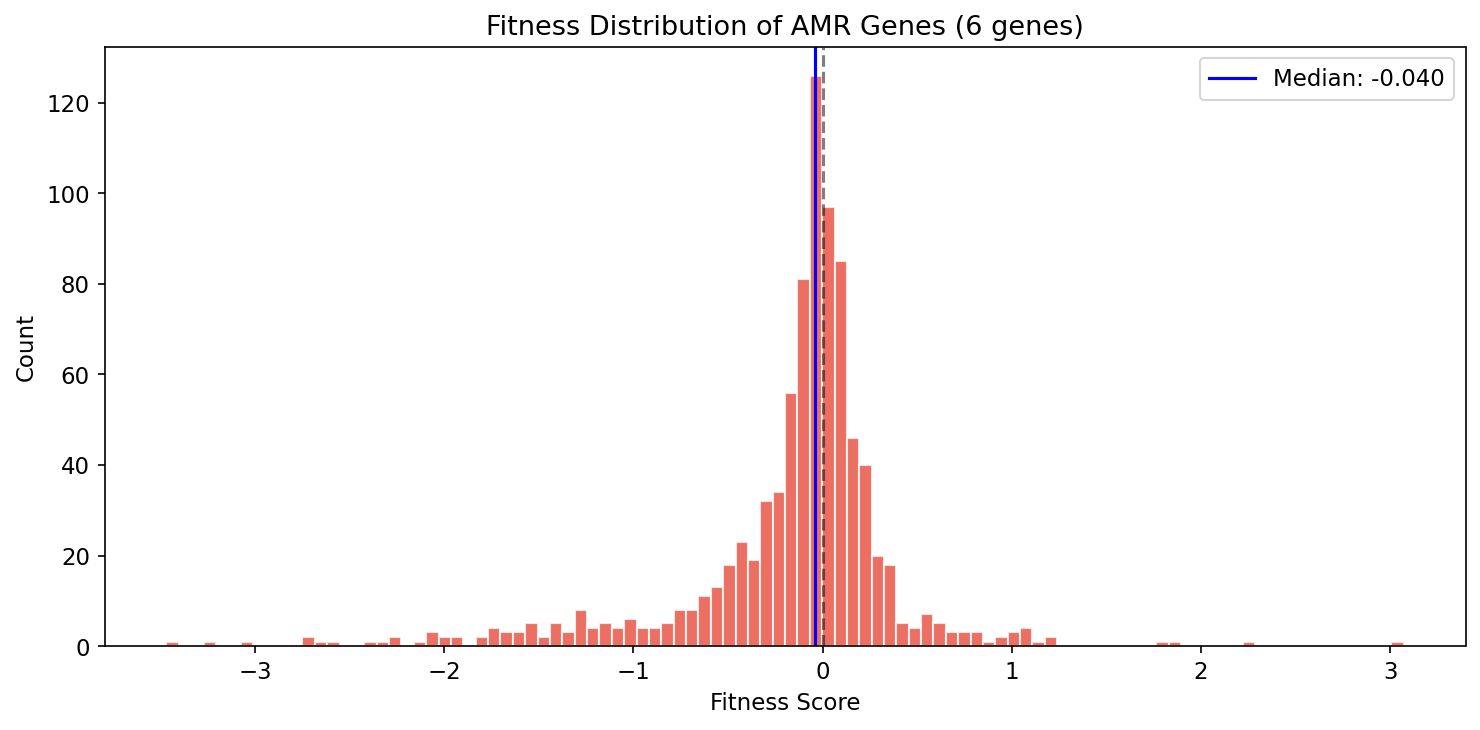

In [4]:
# If we have matches, get fitness data for AMR-annotated genes in those organisms
# Use gene description matching as a fallback (AMR product name in FB gene description)
if len(fb_matches) > 0:
    matched_orgs = fb_matches['orgId'].tolist()
    org_list = "','".join(matched_orgs)
    
    # Get all genes and their fitness for matched organisms
    # FB gene table has: orgId, locusId, sysName, gene, desc
    # Match AMR genes by description keywords
    fb_gene_info = spark.sql(f"""
        SELECT orgId, locusId, gene, `desc`
        FROM kescience_fitnessbrowser.gene
        WHERE orgId IN ('{org_list}')
    """).toPandas()
    
    print(f"Total FB genes in matched organisms: {len(fb_gene_info):,}")
    
    # Get AMR gene names for these species
    amr_gene_names = set(amr[amr['gtdb_species_clade_id'].isin(
        fb_matches['gtdb_species_clade_id'])]['amr_gene'].unique())
    print(f"AMR gene names to search for: {len(amr_gene_names)}")
    
    # Match by gene name (case-insensitive)
    fb_gene_info['gene_lower'] = fb_gene_info['gene'].str.lower()
    amr_gene_lower = {g.lower() for g in amr_gene_names}
    
    fb_amr_genes = fb_gene_info[fb_gene_info['gene_lower'].isin(amr_gene_lower)]
    print(f"FB genes matching AMR gene names: {len(fb_amr_genes):,}")
    
    if len(fb_amr_genes) > 0:
        # Get fitness for these genes
        amr_loci = fb_amr_genes['locusId'].unique().tolist()
        
        def chunked_query(spark, ids, query_template, chunk_size=500):
            results = []
            for i in range(0, len(ids), chunk_size):
                chunk = ids[i:i+chunk_size]
                id_list = "','".join(str(x) for x in chunk)
                query = query_template.format(id_list=f"'{id_list}'")
                results.append(spark.sql(query).toPandas())
            return pd.concat(results, ignore_index=True) if results else pd.DataFrame()
        
        amr_fitness = chunked_query(spark, amr_loci, """
            SELECT orgId, locusId, CAST(fit AS DOUBLE) as fitness, CAST(t AS DOUBLE) as t_score
            FROM kescience_fitnessbrowser.genefitness
            WHERE locusId IN ({id_list})
        """)
        
        print(f"\nFitness measurements for AMR genes: {len(amr_fitness):,}")
        print(f"Organisms: {amr_fitness['orgId'].nunique()}")
        print(f"Genes: {amr_fitness['locusId'].nunique()}")
        
        print(f"\n=== AMR Gene Fitness Summary ===")
        print(f"Mean fitness: {amr_fitness['fitness'].mean():.4f}")
        print(f"Median fitness: {amr_fitness['fitness'].median():.4f}")
        print(f"% with sick phenotype (fitness < -1): {(amr_fitness['fitness'] < -1).mean()*100:.1f}%")
        print(f"% with strong sick (fitness < -2): {(amr_fitness['fitness'] < -2).mean()*100:.1f}%")
        
        amr_fitness.to_csv(DATA_DIR / 'amr_fitness.csv', index=False)
        
        # Visualization
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.hist(amr_fitness['fitness'].dropna(), bins=100, color='#e74c3c', edgecolor='white', alpha=0.8)
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        ax.axvline(amr_fitness['fitness'].median(), color='blue', linestyle='-',
                   label=f'Median: {amr_fitness["fitness"].median():.3f}')
        ax.set_xlabel('Fitness Score')
        ax.set_ylabel('Count')
        ax.set_title(f'Fitness Distribution of AMR Genes ({amr_fitness["locusId"].nunique()} genes)')
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'amr_fitness_distribution.png')
        plt.show()
    else:
        print("No FB genes matched AMR gene names. Skipping fitness analysis.")
else:
    print("No FB-AMR species matches found.")
    print("FB species names may differ from GTDB names (e.g., NCBI vs GTDB nomenclature).")
    print("This analysis would benefit from the FB-pangenome link table in conservation_vs_fitness.")